# Image-Aware AI Agent Memory: From Visual Inputs to Searchable Context

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](#) [![Docs](https://img.shields.io/badge/Docs-Oracle_AI_Agent_Memory-blue)](https://docs.oracle.com/en/database/oracle/agent-memory/26.8/guide/int-use-images.html) [![Oracle AI Agent Memory](https://img.shields.io/badge/Oracle_AI_Agent_Memory-26.8-red)](https://pypi.org/project/oracleagentmemory/26.8.0/)

This notebook demonstrates the image-aware memory capabilities in Oracle AI Agent Memory 26.8. It shows how an agent can store visual evidence, search it through text descriptions or captions, keep raw image bytes out of default retrieval paths, and explicitly hydrate bytes only when an application needs to render or forward the image.

The walkthrough uses a synthetic support-evidence image generated inside the notebook. No customer screenshots, credentials, or private data are embedded in the notebook.


## Runtime Requirement

The image-byte path in Oracle AI Agent Memory validates image inputs before persistence or LLM processing. In version 26.8, that validation requires a POSIX runtime. Run the full notebook on one of these environments:

- macOS
- Linux
- WSL on Windows
- Google Colab
- a Linux container

Native Windows Python can open and inspect the notebook, but the image storage cells should be executed in a POSIX runtime. The runtime check below stops early on unsupported runtimes so the notebook does not produce a long series of misleading partial outputs.


In [1]:
import os
import platform

POSIX_RUNTIME = os.name == "posix"

print("Operating system:", platform.system())
print("POSIX runtime:", POSIX_RUNTIME)

if not POSIX_RUNTIME:
    raise RuntimeError(
        "Oracle AI Agent Memory 26.8 image-byte validation requires a POSIX runtime. "
        "Run this notebook in macOS, Linux, WSL, Google Colab, or a Linux container for the full image-aware demo."
    )


Operating system: Linux
POSIX runtime: True


## What This Notebook Demonstrates

This notebook focuses on the public image-aware behavior that developers need to understand:

- image records are stored in the managed `DOCUMENT` table;
- `MESSAGE.content` can represent ordered text and image content parts;
- image search is text-first, using caller-provided descriptions or generated captions;
- search and default readback do not return raw bytes;
- raw bytes are loaded only when explicitly requested;
- image-aware extraction is configurable and disabled by default.

The runnable path uses a caller-provided image description. That keeps the notebook deterministic and avoids requiring a vision-capable model for caption generation.


## Image-Aware Memory Flow

```text
Application event
      |
      | text + visual evidence
      v
Oracle AI Agent Memory
      |
      | validates image bytes
      | persists image record
      v
Oracle AI Database managed schema
      |
      | DOCUMENT table stores bytes, description, metadata, scope, and TTL
      | RECORD_CHUNKS indexes description or caption
      v
Text-based image search
      |
      | returns ImageRecord metadata and content text
      | does not return raw bytes by default
      v
Explicit byte hydration
      |
      | include_bytes=True or include_image_bytes=True
      v
Application renders or forwards selected images
```


## Database Connection Guide

Use one of these connection paths. The notebook reads the same environment variable names for all options.

### Autonomous AI Database

Use Autonomous AI Database when you want a managed Oracle AI Database target. Provide `DB_USER`, `DB_PASSWORD`, and `DB_DSN`. If your environment requires a wallet, set `DB_WALLET_LOCATION` and confirm your `python-oracledb` setup can connect.

### Oracle AI Database or Local Oracle Database

Use a standard Oracle connection string for a local or provisioned Oracle AI Database environment. This is often the easiest path when you need schema creation and upgrade privileges for an end-to-end notebook run.


## Environment Variables

Create a `.env` file next to the notebook, or set the same variables in Colab secrets / runtime environment. Keep credentials out of the notebook itself.

```text
DB_USER=your_database_user
DB_PASSWORD=your_database_password
DB_DSN=your_database_dsn
MODEL_PROVIDER_API_KEY=your_model_provider_api_key

# Optional aliases also accepted if your environment already uses them.
ORACLE_USER=your_database_user
ORACLE_PASSWORD=your_database_password
ORACLE_DSN=your_database_dsn
OPENAI_API_KEY=your_model_provider_api_key

# Optional but recommended so this image demo does not reuse another memory demo schema.
OAMP_IMAGE_MEMORY_STORE_ID=IMGDEMO268

# Optional model settings.
MEMORY_LLM_MODEL=gpt-4o-mini
MEMORY_EMBEDDING_MODEL=text-embedding-3-small
MEMORY_EMBEDDING_DIMENSION=1536
DB_DISPLAY_NAME=Oracle AI Database
```

`OAMP_IMAGE_MEMORY_STORE_ID` must be 16 characters or fewer, start with a letter, and contain only letters, numbers, and underscores.


## Install the Python Packages

Run this once in a clean Python environment. If the package was already imported before installation, restart the kernel after this cell and run the notebook again from the beginning.


In [2]:
import subprocess
import sys

packages = [
    "oracleagentmemory>=26.8",
    "oracledb>=2.5",
    "python-dotenv",
    "pillow",
    "pandas",
]

subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "--upgrade", "--index-url", "https://pypi.org/simple", *packages, "--quiet"]
)

print("Python packages installed or already available.")


Python packages installed or already available.


## Load Configuration

This cell loads secrets from the environment, validates the demo memory-store name, and centralizes all demo values in `DEMO_CONFIG`. Keeping demo values in one place makes the notebook easier to adapt and keeps reusable identifiers out of the later workflow cells.


In [3]:
import dataclasses
import inspect
import json
import os
import re
import warnings
from pathlib import Path
from uuid import uuid4

import oracledb
import pandas as pd
from dotenv import load_dotenv
from IPython.display import Image, display

warnings.filterwarnings("ignore", category=UserWarning, module="oracledb")

load_dotenv(dotenv_path=Path(".env") if Path(".env").exists() else None)

oracledb.defaults.program = "devrel-developerhub-image-aware-agent-memory"


def env_first(*names, default=None):
    for name in names:
        value = os.getenv(name)
        if value:
            return value
    try:
        from google.colab import userdata

        for name in names:
            value = userdata.get(name)
            if value:
                return value
    except Exception:
        pass
    return default


def validate_memory_store_id(value):
    if not re.fullmatch(r"[A-Za-z][A-Za-z0-9_]{0,15}", value or ""):
        raise RuntimeError(
            "OAMP_IMAGE_MEMORY_STORE_ID must start with a letter, use only letters/numbers/underscores, "
            "and be at most 16 characters. Example: IMGDEMO268"
        )


CONFIG = {
    "DB_USER": env_first("DB_USER", "ORACLE_USER"),
    "DB_PASSWORD": env_first("DB_PASSWORD", "ORACLE_PASSWORD"),
    "DB_DSN": env_first("DB_DSN", "ORACLE_DSN"),
    "DB_WALLET_LOCATION": env_first("DB_WALLET_LOCATION"),
    "DB_DISPLAY_NAME": env_first("DB_DISPLAY_NAME"),
    "MODEL_PROVIDER_API_KEY": env_first("MODEL_PROVIDER_API_KEY", "OPENAI_API_KEY"),
    "MEMORY_LLM_MODEL": env_first("MEMORY_LLM_MODEL", "OAMP_LLM_MODEL", default="gpt-4o-mini"),
    "MEMORY_EMBEDDING_MODEL": env_first("MEMORY_EMBEDDING_MODEL", "EMBED_MODEL", default="text-embedding-3-small"),
    "MEMORY_EMBEDDING_DIMENSION": int(env_first("MEMORY_EMBEDDING_DIMENSION", "EMBED_DIM", default="1536")),
    "MEMORY_STORE_ID": env_first("OAMP_IMAGE_MEMORY_STORE_ID", default="IMGDEMO268"),
}

missing = [name for name in ["DB_USER", "DB_PASSWORD", "DB_DSN", "MODEL_PROVIDER_API_KEY"] if not CONFIG[name]]
if missing:
    raise RuntimeError("Missing required environment variables: " + ", ".join(missing))

validate_memory_store_id(CONFIG["MEMORY_STORE_ID"])

DEMO_CONFIG = {
    "case_id": env_first("OAMP_IMAGE_DEMO_CASE_ID", default="CASE-IMG-268"),
    "user_id": env_first("OAMP_IMAGE_DEMO_USER_ID", default="image-demo-user"),
    "agent_id": env_first("OAMP_IMAGE_DEMO_AGENT_ID", default="support-agent"),
    "thread_id": env_first("OAMP_IMAGE_DEMO_THREAD_ID", default=f"thread-image-demo-{uuid4().hex[:8]}"),
    "image_id": env_first("OAMP_IMAGE_DEMO_IMAGE_ID", default=f"image-evidence-{uuid4().hex[:10]}"),
    "region": env_first("OAMP_IMAGE_DEMO_REGION", default="eu-frankfurt-1"),
    "severity": env_first("OAMP_IMAGE_DEMO_SEVERITY", default="high"),
    "scenario": env_first("OAMP_IMAGE_DEMO_SCENARIO", default="checkout timeout spikes"),
}

print("Configuration loaded")
print("Database target:", CONFIG["DB_DISPLAY_NAME"] or "derived from DSN")
print("Memory store ID:", CONFIG["MEMORY_STORE_ID"])
print("LLM model:", CONFIG["MEMORY_LLM_MODEL"])
print("Embedding model:", CONFIG["MEMORY_EMBEDDING_MODEL"])
print("Embedding dimension:", CONFIG["MEMORY_EMBEDDING_DIMENSION"])
print("Program identifier:", oracledb.defaults.program)
print("Demo case:", DEMO_CONFIG["case_id"])


Configuration loaded
Database target: derived from DSN
Memory store ID: IMGDEMO268
LLM model: gpt-5.4
Embedding model: text-embedding-3-small
Embedding dimension: 1536
Program identifier: devrel-developerhub-image-aware-agent-memory
Demo case: CASE-IMG-268


## Verify Package Version

The image APIs used here require Oracle AI Agent Memory 26.8 or later. The version check fails early if the runtime has an older package installed.


In [4]:
import importlib.metadata as package_metadata

package_version = package_metadata.version("oracleagentmemory")
print("oracleagentmemory version:", package_version)

version_parts = tuple(int(part) for part in package_version.split(".")[:2])
if version_parts < (26, 8):
    raise RuntimeError("Install oracleagentmemory 26.8 or later before running this notebook.")


oracleagentmemory version: 26.8.0


## Connect to Oracle AI Database

This preflight step checks the database connection, basic table privileges, and whether the selected Agent Memory managed schema already exists. A missing managed schema is acceptable when the database user has privileges to create it.


In [5]:
pool_kwargs = {
    "user": CONFIG["DB_USER"],
    "password": CONFIG["DB_PASSWORD"],
    "dsn": CONFIG["DB_DSN"],
    "min": 1,
    "max": 4,
    "increment": 1,
}
if CONFIG["DB_WALLET_LOCATION"]:
    pool_kwargs["config_dir"] = CONFIG["DB_WALLET_LOCATION"]
    pool_kwargs["wallet_location"] = CONFIG["DB_WALLET_LOCATION"]

db_pool = oracledb.create_pool(**pool_kwargs)


def is_freesql_connection(dsn):
    return "freesql" in str(dsn).lower()


IS_FREESQL = is_freesql_connection(CONFIG["DB_DSN"])
DATABASE_DISPLAY_NAME = CONFIG["DB_DISPLAY_NAME"] or ("FreeSQL" if IS_FREESQL else "Oracle AI Database")


def fetch_rows(sql, **params):
    with db_pool.acquire() as connection:
        with connection.cursor() as cursor:
            cursor.execute(sql, params)
            return cursor.fetchall()


def run_preflight_check(name, fn, success, failure):
    try:
        detail = fn()
        return {"check": name, "status": "PASS", "detail": detail, "implication": success}
    except Exception as exc:
        return {"check": name, "status": "FAIL", "detail": f"{type(exc).__name__}: {exc}", "implication": failure}


def check_connection():
    rows = fetch_rows("SELECT 1 FROM dual")
    if not rows:
        raise RuntimeError("SELECT 1 FROM dual returned no rows.")
    return f"Connected to {DATABASE_DISPLAY_NAME}"


def check_table_operations():
    test_table = f"OAM_IMAGE_CHECK_{uuid4().hex[:8].upper()}"
    try:
        with db_pool.acquire() as connection:
            with connection.cursor() as cursor:
                cursor.execute(f"CREATE TABLE {test_table} (id NUMBER PRIMARY KEY, note VARCHAR2(100))")
                cursor.execute(
                    f"INSERT INTO {test_table} (id, note) VALUES (:id, :note)",
                    id=1,
                    note="image memory permission check",
                )
                row_count = cursor.execute(f"SELECT COUNT(*) FROM {test_table}").fetchone()[0]
                if row_count != 1:
                    raise RuntimeError("Table permission check returned an unexpected row count.")
            connection.commit()
        return "created, inserted, selected, and dropped a small table"
    finally:
        try:
            with db_pool.acquire() as cleanup_connection:
                with cleanup_connection.cursor() as cursor:
                    cursor.execute(f"DROP TABLE {test_table} PURGE")
                cleanup_connection.commit()
        except oracledb.Error:
            pass


def managed_schema_exists(memory_store_id):
    rows = fetch_rows(
        '''
        SELECT table_name
        FROM user_tables
        WHERE table_name LIKE :prefix
        FETCH FIRST 1 ROWS ONLY
        ''',
        prefix=f"{memory_store_id.upper()}_%",
    )
    return bool(rows)


MANAGED_SCHEMA_EXISTS = managed_schema_exists(CONFIG["MEMORY_STORE_ID"])

preflight_rows = [
    run_preflight_check(
        "connection",
        check_connection,
        "python-oracledb can connect to the configured database.",
        "Fix the database connection values before continuing.",
    ),
    run_preflight_check(
        "table_operations",
        check_table_operations,
        "The schema can create and manage normal user tables.",
        "The schema cannot run the basic table operations needed by this notebook.",
    ),
    {
        "check": "managed_schema_exists",
        "status": "PASS" if MANAGED_SCHEMA_EXISTS else "MISSING",
        "detail": f"memory_store_id={CONFIG['MEMORY_STORE_ID']}",
        "implication": "The notebook can reuse the existing Agent Memory managed schema."
        if MANAGED_SCHEMA_EXISTS
        else "The managed schema was not found and will be created if privileges allow it.",
    },
    {
        "check": "database_path",
        "status": "FREESQL" if IS_FREESQL else "FULL_DATABASE",
        "detail": DATABASE_DISPLAY_NAME,
        "implication": "FreeSQL is convenient for tutorials; schema privileges may vary."
        if IS_FREESQL
        else "The selected database path should support full schema initialization when privileges are present.",
    },
]

preflight_df = pd.DataFrame(preflight_rows)
display(preflight_df)

if (preflight_df["status"] == "FAIL").any():
    raise RuntimeError("Resolve failed database preflight checks before continuing.")


,check,status,detail,implication
0,connection,PASS,Connected to Oracle AI Database,python-oracledb can connect to the configured ...
1,table_operations,PASS,"created, inserted, selected, and dropped a sma...",The schema can create and manage normal user t...
2,managed_schema_exists,PASS,memory_store_id=IMGDEMO268,The notebook can reuse the existing Agent Memo...
3,database_path,FULL_DATABASE,Oracle AI Database,The selected database path should support full...


## Create the Agent Memory Client

The client below configures database-backed Agent Memory with vector search. Image input limits are set explicitly so developers can see where raw-image safety controls belong. This notebook uses caller-provided image descriptions, so a vision-capable model is not required for the main path.


In [6]:
from oracleagentmemory.core import (
    ImageInputLimitConfig,
    MemoryExtractionConfig,
    OracleAgentMemory,
    OracleDBMemoryStore,
    SchemaPolicy,
    SearchStrategy,
)
from oracleagentmemory.core.embedders import Embedder
from oracleagentmemory.core.llms import Llm, LlmApiType

image_input_limits = ImageInputLimitConfig(
    max_raw_image_bytes=10 * 1024 * 1024,
    max_images_per_llm_request=20,
    max_total_raw_image_bytes_per_llm_request=50 * 1024 * 1024,
)

llm_kwargs = {
    "model": CONFIG["MEMORY_LLM_MODEL"],
    "api_key": CONFIG["MODEL_PROVIDER_API_KEY"],
    "temperature": 0,
    "max_tokens": 2_000,
    "image_input_limit_config": image_input_limits,
}
if os.getenv("MEMORY_LLM_API_BASE"):
    llm_kwargs["api_base"] = os.getenv("MEMORY_LLM_API_BASE")
if os.getenv("MEMORY_LLM_API_TYPE", "chat_completions") == "responses":
    llm_kwargs["api_type"] = LlmApiType.RESPONSES
if os.getenv("MEMORY_LLM_SUPPORTS_VISION"):
    llm_kwargs["supports_vision"] = os.getenv("MEMORY_LLM_SUPPORTS_VISION").lower() == "true"

memory_llm = Llm(**llm_kwargs)

embedder = Embedder(
    model=CONFIG["MEMORY_EMBEDDING_MODEL"],
    api_key=CONFIG["MODEL_PROVIDER_API_KEY"],
    embedding_dimension=CONFIG["MEMORY_EMBEDDING_DIMENSION"],
    max_input_tokens=512,
    normalize=True,
)

schema_policy = SchemaPolicy.REQUIRE_EXISTING if MANAGED_SCHEMA_EXISTS else SchemaPolicy.CREATE_IF_NECESSARY

store = OracleDBMemoryStore(
    pool=db_pool,
    embedder=embedder,
    memory_store_id=CONFIG["MEMORY_STORE_ID"],
    schema_policy=schema_policy,
    search_strategy=SearchStrategy.VECTOR,
    vector_dim=CONFIG["MEMORY_EMBEDDING_DIMENSION"],
)

memory = OracleAgentMemory(
    store=store,
    llm=memory_llm,
    memory_extraction_config=MemoryExtractionConfig(
        memory_extraction_frequency=1,
        enable_context_summary=False,
        extract_memories=False,
    ),
    image_input_limit_config=image_input_limits,
)

print("Database-backed image memory client: READY")
print("Managed schema policy:", schema_policy)
print("Image limits: 10 MiB per image, 20 images per LLM request, 50 MiB total per LLM request")


Database-backed image memory client: READY
Managed schema policy: SchemaPolicy.REQUIRE_EXISTING
Image limits: 10 MiB per image, 20 images per LLM request, 50 MiB total per LLM request


## Verify Image-Aware APIs

Before storing data, the notebook verifies the image APIs it will use. This catches older package versions or unexpected runtime mismatches early.


In [7]:
def has_parameter(callable_obj, parameter_name):
    try:
        return parameter_name in inspect.signature(callable_obj).parameters
    except (TypeError, ValueError):
        return False

from oracleagentmemory.apis.message import ImageContent, ImageMimeType, TextContent

api_checks = pd.DataFrame(
    [
        {"Capability": "Add standalone image records", "Check": "OracleAgentMemory.add_image_async", "Available": hasattr(memory, "add_image_async")},
        {"Capability": "List image records", "Check": "OracleAgentMemory.list_images_async", "Available": hasattr(memory, "list_images_async")},
        {"Capability": "Hydrate image bytes explicitly", "Check": "list_images_async(..., include_bytes=...)", "Available": has_parameter(memory.list_images_async, "include_bytes")},
        {"Capability": "Update image description or metadata", "Check": "OracleAgentMemory.update_image_async", "Available": hasattr(memory, "update_image_async")},
        {"Capability": "Search selected record types", "Check": "search(..., record_types=...)", "Available": has_parameter(memory.search, "record_types")},
        {"Capability": "Ordered message image content", "Check": "ImageContent + TextContent", "Available": ImageContent is not None and TextContent is not None},
    ]
)

display(api_checks)

if not api_checks["Available"].all():
    missing = ", ".join(api_checks.loc[~api_checks["Available"], "Capability"])
    raise RuntimeError("Install oracleagentmemory 26.8 or later. Missing capabilities: " + missing)

print("Image-aware memory APIs: READY")


,Capability,Check,Available
0,Add standalone image records,OracleAgentMemory.add_image_async,True
1,List image records,OracleAgentMemory.list_images_async,True
2,Hydrate image bytes explicitly,"list_images_async(..., include_bytes=...)",True
3,Update image description or metadata,OracleAgentMemory.update_image_async,True
4,Search selected record types,"search(..., record_types=...)",True
5,Ordered message image content,ImageContent + TextContent,True


Image-aware memory APIs: READY


## Generate a Synthetic Demo Image

The package validates and stores real image bytes. To keep this notebook safe for a public repository, the image is generated locally from demo configuration instead of using a real support screenshot.


Demo image file: case-img-268_support_evidence.png
Demo image byte length: 58195


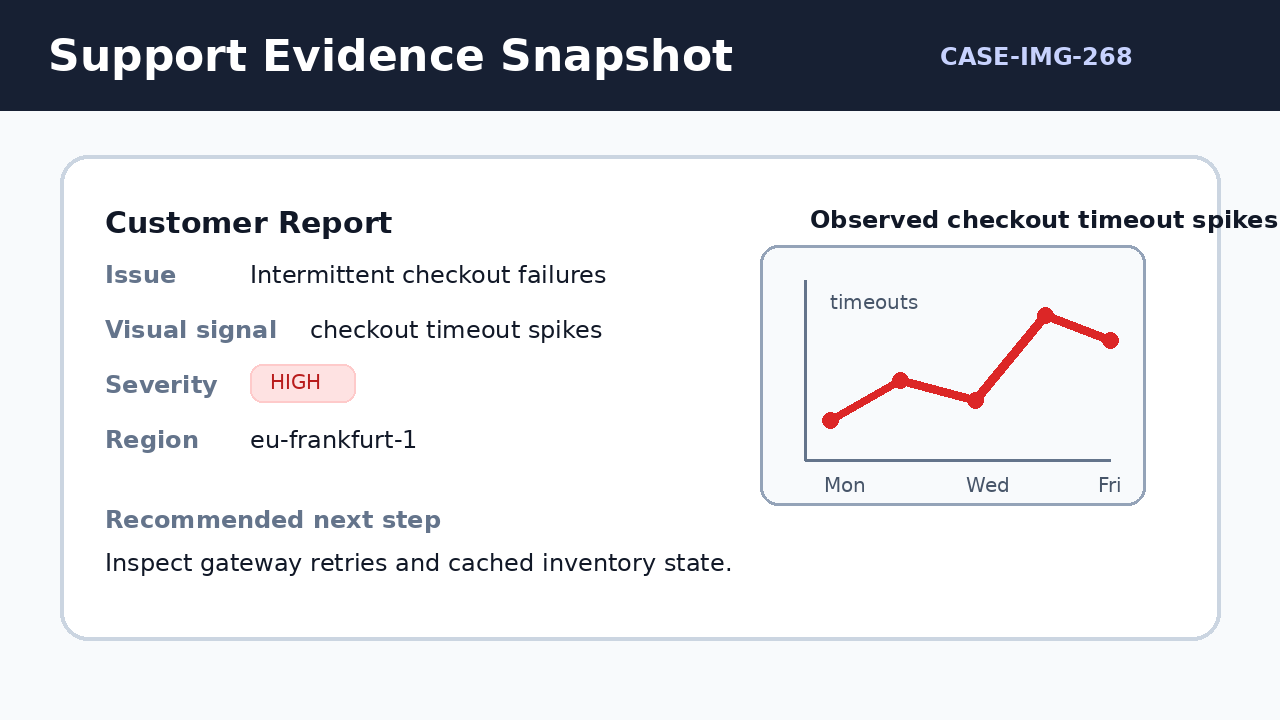

In [8]:
from PIL import Image as PILImage, ImageDraw, ImageFont

ARTIFACT_DIR = Path("generated_artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)
DEMO_IMAGE_PATH = ARTIFACT_DIR / f"{DEMO_CONFIG['case_id'].lower()}_support_evidence.png"

img = PILImage.new("RGB", (1280, 720), "#f8fafc")
draw = ImageDraw.Draw(img)

def load_font(size, bold=False):
    candidates = [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf" if bold else "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        "arialbd.ttf" if bold else "arial.ttf",
    ]
    for candidate in candidates:
        try:
            return ImageFont.truetype(candidate, size)
        except OSError:
            continue
    return ImageFont.load_default()

title_font = load_font(44, bold=True)
heading_font = load_font(30, bold=True)
label_font = load_font(24, bold=True)
body_font = load_font(24)
small_font = load_font(20)

draw.rectangle((0, 0, 1280, 110), fill="#172033")
draw.text((48, 30), "Support Evidence Snapshot", fill="white", font=title_font)
draw.text((940, 42), DEMO_CONFIG["case_id"], fill="#c7d2fe", font=label_font)

draw.rounded_rectangle((60, 155, 1220, 640), radius=28, fill="white", outline="#cbd5e1", width=4)

draw.text((105, 205), "Customer Report", fill="#111827", font=heading_font)
draw.text((105, 260), "Issue", fill="#64748b", font=label_font)
draw.text((250, 260), "Intermittent checkout failures", fill="#111827", font=body_font)
draw.text((105, 315), "Visual signal", fill="#64748b", font=label_font)
draw.text((310, 315), DEMO_CONFIG["scenario"], fill="#111827", font=body_font)
draw.text((105, 370), "Severity", fill="#64748b", font=label_font)
draw.rounded_rectangle((250, 364, 355, 402), radius=12, fill="#fee2e2", outline="#fecaca", width=2)
draw.text((270, 370), DEMO_CONFIG["severity"].upper(), fill="#b91c1c", font=small_font)
draw.text((105, 425), "Region", fill="#64748b", font=label_font)
draw.text((250, 425), DEMO_CONFIG["region"], fill="#111827", font=body_font)
draw.text((105, 505), "Recommended next step", fill="#64748b", font=label_font)
draw.text((105, 548), "Inspect gateway retries and cached inventory state.", fill="#111827", font=body_font)

chart_left, chart_top, chart_right, chart_bottom = 760, 245, 1145, 505
draw.rounded_rectangle((chart_left, chart_top, chart_right, chart_bottom), radius=18, fill="#f8fafc", outline="#94a3b8", width=3)
draw.text((810, 205), "Observed checkout timeout spikes", fill="#111827", font=label_font)

axis_color = "#64748b"
draw.line((chart_left + 45, chart_bottom - 45, chart_right - 35, chart_bottom - 45), fill=axis_color, width=3)
draw.line((chart_left + 45, chart_top + 35, chart_left + 45, chart_bottom - 45), fill=axis_color, width=3)

points = [
    (chart_left + 70, chart_bottom - 85),
    (chart_left + 140, chart_bottom - 125),
    (chart_left + 215, chart_bottom - 105),
    (chart_left + 285, chart_bottom - 190),
    (chart_left + 350, chart_bottom - 165),
]
draw.line(points, fill="#dc2626", width=9, joint="curve")
for x, y in points:
    draw.ellipse((x - 8, y - 8, x + 8, y + 8), fill="#dc2626")

draw.text((chart_left + 64, chart_bottom - 32), "Mon", fill="#475569", font=small_font)
draw.text((chart_left + 206, chart_bottom - 32), "Wed", fill="#475569", font=small_font)
draw.text((chart_left + 338, chart_bottom - 32), "Fri", fill="#475569", font=small_font)
draw.text((chart_left + 70, chart_top + 45), "timeouts", fill="#475569", font=small_font)

img.save(DEMO_IMAGE_PATH, format="PNG")
image_bytes = DEMO_IMAGE_PATH.read_bytes()

print("Demo image file:", DEMO_IMAGE_PATH.name)
print("Demo image byte length:", len(image_bytes))
display(Image(filename=str(DEMO_IMAGE_PATH), width=860))


## Store a Standalone Image Record

The caller-provided description is the searchable representation of the image. It is persisted and indexed directly, which makes this path deterministic and avoids requiring generated captions for the main demo.


In [9]:
image_description = (
    f"Support evidence screenshot for case {DEMO_CONFIG['case_id']}. "
    f"The image shows intermittent checkout failures, {DEMO_CONFIG['scenario']}, "
    f"severity {DEMO_CONFIG['severity']}, region {DEMO_CONFIG['region']}, "
    "and a recommendation to inspect gateway retries and cached inventory state."
)

# This first write is intentionally a standalone image record. It is scoped to
# the demo user and agent, but not to a thread. Thread-attached image content is
# demonstrated later with OracleThread.add_messages_async(...).
stored_image_id = await memory.add_image_async(
    image=image_bytes,
    description=image_description,
    mime_type=ImageMimeType.PNG,
    image_id=DEMO_CONFIG["image_id"],
    user_id=DEMO_CONFIG["user_id"],
    agent_id=DEMO_CONFIG["agent_id"],
    metadata={
        "demo": "image-aware-memory",
        "case_id": DEMO_CONFIG["case_id"],
        "image_id": DEMO_CONFIG["image_id"],
        "region": DEMO_CONFIG["region"],
        "severity": DEMO_CONFIG["severity"],
        "source": "synthetic-notebook-image",
    },
)

print("Stored standalone image ID:", stored_image_id)
print("Description length:", len(image_description))


Stored standalone image ID: image-evidence-1b83387117
Description length: 237


## Inspect the Managed DOCUMENT Table

Oracle AI Agent Memory persists image bytes in the managed `DOCUMENT` table. This query verifies the row, document type, description, byte length, status, and metadata without printing the raw BLOB.


In [10]:
def safe_db_object_name(name):
    candidate = name.upper()
    if not re.fullmatch(r"[A-Z][A-Z0-9_$#]{0,127}", candidate):
        raise ValueError(f"Unsafe Oracle object name: {name}")
    return candidate

DOCUMENT_TABLE = safe_db_object_name(f"{CONFIG['MEMORY_STORE_ID']}_DOCUMENT")

with db_pool.acquire() as connection:
    with connection.cursor() as cursor:
        rows = cursor.execute(
            f'''
            SELECT
                record_id,
                document_type,
                description,
                DBMS_LOB.GETLENGTH(blob) AS byte_length,
                status,
                JSON_SERIALIZE(metadata RETURNING VARCHAR2(4000)) AS metadata_json
            FROM {DOCUMENT_TABLE}
            WHERE record_id = :record_id
            ''',
            record_id=stored_image_id,
        ).fetchall()

columns = ["record_id", "document_type", "description", "byte_length", "status", "metadata_json"]
document_df = pd.DataFrame(rows, columns=columns)
display(document_df)

if document_df.empty:
    raise RuntimeError("The stored image was not found in the managed DOCUMENT table.")


,record_id,document_type,description,byte_length,status,metadata_json
0,image-evidence-1b83387117,image,Support evidence screenshot for case CASE-IMG-...,58195,valid,"{""demo"":""image-aware-memory"",""case_id"":""CASE-I..."


## List Image Records Without Raw Bytes

Default image readback is compact. It returns identifiers, description, metadata, and scope, but does not hydrate raw bytes. This is the safe default for search results, summaries, and prompt context.


In [11]:
def object_to_safe_dict(obj):
    if isinstance(obj, dict):
        data = obj
    elif hasattr(obj, "model_dump"):
        data = obj.model_dump()
    elif dataclasses.is_dataclass(obj):
        data = dataclasses.asdict(obj)
    elif hasattr(obj, "_to_dict"):
        data = obj._to_dict()
    elif hasattr(obj, "__dict__"):
        data = {k: v for k, v in vars(obj).items() if not k.startswith("_")}
    else:
        data = {"value": str(obj)}

    safe = {}
    for key, value in data.items():
        if isinstance(value, (bytes, bytearray)):
            safe[key] = f"<bytes omitted: {len(value)} bytes>"
        elif isinstance(value, list):
            safe[key] = [
                object_to_safe_dict(item)
                if not isinstance(item, (str, int, float, bool, type(None)))
                else item
                for item in value
            ]
        else:
            safe[key] = value
    return safe


def bytes_present(obj):
    data = object_to_safe_dict(obj)
    return any(isinstance(value, str) and value.startswith("<bytes omitted:") for value in data.values())


def show_existing_columns(df, preferred_columns):
    existing = [column for column in preferred_columns if column in df.columns]
    return df[existing] if existing else df


images_without_bytes = await memory.list_images_async(
    image_id=stored_image_id,
    user_id=DEMO_CONFIG["user_id"],
    agent_id=DEMO_CONFIG["agent_id"],
    include_bytes=False,
    limit=5,
)

without_bytes_df = pd.DataFrame([object_to_safe_dict(record) for record in images_without_bytes])
display(show_existing_columns(without_bytes_df, ["id", "record_type", "content", "mime_type", "bytes", "message_id", "user_id", "agent_id"]))

print("Image records returned:", len(images_without_bytes))
print("Default readback includes raw bytes:", any(bytes_present(record) for record in images_without_bytes))


,id,record_type,content,mime_type,bytes,message_id,user_id,agent_id
0,image-evidence-1b83387117,image,Support evidence screenshot for case CASE-IMG-...,ImageMimeType.PNG,None,None,image-demo-user,support-agent


Image records returned: 1
Default readback includes raw bytes: False


## Search for the Image by Semantic Text

Image search remains text-based. The description or generated caption is chunked and indexed, then image records participate in the same vector, keyword, or hybrid search path as other records.


In [12]:
def result_text(result):
    for attr in ("content", "text", "description", "summary"):
        value = getattr(result, attr, None)
        if value:
            return value
    if hasattr(result, "format_content"):
        try:
            return result.format_content()
        except Exception:
            pass
    return str(result)


def result_id(result):
    for attr in ("record_id", "id", "memory_id", "image_id"):
        value = getattr(result, attr, None)
        if value:
            return value
    return None


search_query = f"Which image evidence shows {DEMO_CONFIG['scenario']} in {DEMO_CONFIG['region']}?"

image_results = await memory.search_async(
    query=search_query,
    record_types=["image"],
    user_id=DEMO_CONFIG["user_id"],
    agent_id=DEMO_CONFIG["agent_id"],
    metadata_filter={"image_id": stored_image_id},
    max_results=5,
)

search_rows = [
    {
        "rank": idx + 1,
        "record_id": result_id(result),
        "matched_current_demo_image": result_id(result) == stored_image_id,
        "matched_text": result_text(result)[:500],
    }
    for idx, result in enumerate(image_results)
]
search_df = pd.DataFrame(search_rows, columns=["rank", "record_id", "matched_current_demo_image", "matched_text"])
display(search_df)

if not image_results:
    raise RuntimeError("Image search returned no results for the current demo image.")

print("Image search matched current demo image:", result_id(image_results[0]) == stored_image_id)


,rank,record_id,matched_current_demo_image,matched_text
0,1,image-evidence-1b83387117,True,Support evidence screenshot for case CASE-IMG-...


Image search matched current demo image: True


## Hydrate Raw Image Bytes Explicitly

Raw bytes are loaded only when the application asks for them. This cell reloads the same image with `include_bytes=True` and reports the byte length without printing the bytes themselves.


In [13]:
images_with_bytes = await memory.list_images_async(
    image_id=stored_image_id,
    user_id=DEMO_CONFIG["user_id"],
    agent_id=DEMO_CONFIG["agent_id"],
    include_bytes=True,
    limit=1,
)

hydrated_rows = []
for record in images_with_bytes:
    safe_record = object_to_safe_dict(record)
    hydrated_rows.append(
        {
            "id": safe_record.get("id"),
            "mime_type": safe_record.get("mime_type"),
            "content": safe_record.get("content"),
            "hydrated_bytes": safe_record.get("bytes") or safe_record.get("image_bytes"),
        }
    )

hydrated_df = pd.DataFrame(hydrated_rows, columns=["id", "mime_type", "content", "hydrated_bytes"])
display(hydrated_df)

byte_fields = {
    key: value
    for record in images_with_bytes
    for key, value in object_to_safe_dict(record).items()
    if isinstance(value, str) and value.startswith("<bytes omitted:")
}

print("Explicit byte hydration requested:", bool(byte_fields))
print("Hydrated byte summary:", byte_fields)


,id,mime_type,content,hydrated_bytes
0,image-evidence-1b83387117,ImageMimeType.PNG,Support evidence screenshot for case CASE-IMG-...,<bytes omitted: 58195 bytes>


Explicit byte hydration requested: True
Hydrated byte summary: {'bytes': '<bytes omitted: 58195 bytes>'}


## Update the Image Description

Descriptions can be refined when an application receives better structured evidence. Updating the description changes the searchable representation while keeping raw bytes protected by explicit hydration.


In [14]:
updated_description = (
    image_description
    + " The visual evidence also highlights that checkout impact correlates with gateway retry behavior."
)

updated_image_id = await memory.update_image_async(
    image_id=stored_image_id,
    description=updated_description,
    metadata={
        "demo": "image-aware-memory",
        "case_id": DEMO_CONFIG["case_id"],
        "image_id": stored_image_id,
        "region": DEMO_CONFIG["region"],
        "severity": DEMO_CONFIG["severity"],
        "source": "synthetic-notebook-image",
        "review_status": "description-updated",
    },
)

updated_records = await memory.list_images_async(
    image_id=stored_image_id,
    user_id=DEMO_CONFIG["user_id"],
    agent_id=DEMO_CONFIG["agent_id"],
    include_bytes=False,
    limit=1,
)

print("Updated image ID:", updated_image_id)
display(pd.DataFrame([object_to_safe_dict(record) for record in updated_records]))


Updated image ID: image-evidence-1b83387117


,id,record_type,content,timestamp,metadata,status,linked_results,thread_id,user_id,agent_id,message_id,mime_type,bytes
0,image-evidence-1b83387117,image,Support evidence screenshot for case CASE-IMG-...,2026-10-04T13:17:26.393856,"{'demo': 'image-aware-memory', 'case_id': 'CAS...",RecordStatus.VALID,(),None,image-demo-user,support-agent,None,ImageMimeType.PNG,None


## Add a Message With Ordered Text and Image Content

Images can also be attached to messages. The message content is an ordered list of content parts, so an application can preserve the relationship between text and image evidence. Default message readback omits image bytes; `include_image_bytes=True` hydrates them explicitly.


In [15]:
thread = memory.create_thread(
    thread_id=DEMO_CONFIG["thread_id"],
    user_id=DEMO_CONFIG["user_id"],
    agent_id=DEMO_CONFIG["agent_id"],
)

message_content = [
    TextContent(
        text=f"Customer attached visual evidence for {DEMO_CONFIG['scenario']} in {DEMO_CONFIG['region']}."
    )._to_dict(),
    ImageContent(
        bytes=image_bytes,
        mime_type=ImageMimeType.PNG,
        description=image_description,
    )._to_dict(),
]

message_ids = await thread.add_messages_async(
    [
        {
            "role": "user",
            "content": message_content,
            "metadata": {"case_id": DEMO_CONFIG["case_id"], "demo": "image-aware-message-content"},
        }
    ]
)

messages_without_image_bytes = await thread.get_messages_async(include_image_bytes=False)
messages_with_image_bytes = await thread.get_messages_async(include_image_bytes=True)

print("Message IDs:", message_ids)
print("Messages without image bytes:", len(messages_without_image_bytes))
print("Messages with image bytes requested:", len(messages_with_image_bytes))


Message IDs: ['1fa3c4b3-d444-49b1-914e-667f15a21e92']
Messages without image bytes: 1
Messages with image bytes requested: 1


## Inspect Message Content Parts

This cell summarizes the ordered content parts without printing raw image bytes. It verifies that message readback can preserve text/image structure and that byte hydration remains explicit.


In [16]:
message_id = message_ids[0]

with db_pool.acquire() as conn:
    message_document_rows = conn.cursor().execute(
        f"""
        SELECT
            record_id,
            document_type,
            message_id,
            DBMS_LOB.GETLENGTH(blob) AS byte_length,
            status
        FROM {DOCUMENT_TABLE}
        WHERE message_id = :message_id
        ORDER BY created_at
        """,
        message_id=message_id,
    ).fetchall()

message_document_df = pd.DataFrame(
    message_document_rows,
    columns=["record_id", "document_type", "message_id", "byte_length", "status"],
)

message_demo_df = pd.DataFrame(
    [
        {
            "message_id": message_id,
            "submitted_text_parts": 1,
            "submitted_image_parts": 1,
            "stored_image_documents": len(message_document_df),
            "default_message_readback_count": len(messages_without_image_bytes),
            "hydrated_message_readback_count": len(messages_with_image_bytes),
        }
    ]
)

display(message_demo_df)
display(message_document_df)

if message_document_df.empty:
    raise RuntimeError("The multimodal message was added, but no image document row was linked to the message.")

print("Message image persisted in DOCUMENT with message_id:", message_id)


,message_id,submitted_text_parts,submitted_image_parts,stored_image_documents,default_message_readback_count,hydrated_message_readback_count
0,1fa3c4b3-d444-49b1-914e-667f15a21e92,1,1,1,1,1


,record_id,document_type,message_id,byte_length,status
0,ab0f0e37-2592-4e40-8e64-c1c7c580589e,image,1fa3c4b3-d444-49b1-914e-667f15a21e92,58195,valid


Message image persisted in DOCUMENT with message_id: 1fa3c4b3-d444-49b1-914e-667f15a21e92


## Optional: Image-Aware Extraction Modes

This notebook keeps automatic extraction disabled so the image storage and retrieval behavior is easy to inspect. In applications, image-aware extraction is controlled through `memory_extraction_image_context`:

- `DISABLED`: image parts do not participate in memory extraction;
- `CAPTION`: descriptions/captions are used as text context;
- `IMAGE`: original image parts are sent to a vision-capable LLM;
- `MEMORY`: image-specific memory extraction path, when supported by the configured release path.

Use caption-based extraction when you want deterministic text-only prompts. Use image-based extraction only when the configured LLM supports vision and the application has approved the image-data egress path.


In [17]:
from oracleagentmemory.core import MemoryExtractionConfig

extraction_positioning = pd.DataFrame(
    [
        {
            "capability": "Image storage",
            "demonstrated_here": True,
            "what_to_notice": "raw image bytes are validated and persisted in DOCUMENT",
        },
        {
            "capability": "Text-based image retrieval",
            "demonstrated_here": True,
            "what_to_notice": "search matches the image through its description/caption text",
        },
        {
            "capability": "Message content with ordered text and image parts",
            "demonstrated_here": True,
            "what_to_notice": "a single user message can contain text followed by image evidence",
        },
        {
            "capability": "Automatic image-aware memory extraction",
            "demonstrated_here": False,
            "what_to_notice": "kept out of this storage/retrieval notebook so results do not depend on a vision-model setup",
        },
    ]
)

display(extraction_positioning)


,capability,demonstrated_here,what_to_notice
0,Image storage,True,raw image bytes are validated and persisted in...
1,Text-based image retrieval,True,search matches the image through its descripti...
2,Message content with ordered text and image parts,True,a single user message can contain text followe...
3,Automatic image-aware memory extraction,False,kept out of this storage/retrieval notebook so...


## Output Review Checklist

A successful run should show:

- the database connection and table-operation checks pass;
- the Agent Memory client initializes with schema version support for image records;
- the synthetic PNG is generated locally;
- `add_image_async` stores one image record;
- the managed `DOCUMENT` table contains the image metadata and BLOB length;
- `list_images_async(..., include_bytes=False)` returns compact records without raw bytes;
- semantic search returns the image from text query;
- `list_images_async(..., include_bytes=True)` hydrates bytes only when explicitly requested;
- a thread message can preserve ordered text and image content parts.


In [18]:
top_image_result_id = result_id(image_results[0]) if image_results else "no search result"
hydrated_detail = next(iter(byte_fields.values()), "no byte field hydrated")
document_bytes = int(document_df.iloc[0]["byte_length"]) if len(document_df) else 0
message_document_count = len(message_document_df) if "message_document_df" in globals() else 0

summary = pd.DataFrame(
    [
        {"capability": "Database connection", "evidence": DATABASE_DISPLAY_NAME},
        {"capability": "Agent Memory schema", "evidence": CONFIG["MEMORY_STORE_ID"]},
        {"capability": "Standalone image record", "evidence": stored_image_id},
        {"capability": "DOCUMENT persistence", "evidence": f"{len(document_df)} standalone row with {document_bytes} stored bytes"},
        {"capability": "Default byte omission", "evidence": f"raw bytes returned by default: {any(bytes_present(record) for record in images_without_bytes)}"},
        {"capability": "Semantic image search", "evidence": f"{len(image_results)} current image result(s), top ID {top_image_result_id}"},
        {"capability": "Explicit byte hydration", "evidence": hydrated_detail},
        {"capability": "Multimodal message content", "evidence": f"{message_document_count} image document row linked to message {message_ids[0]}"},
    ]
)

display(summary)


,capability,evidence
0,Database connection,Oracle AI Database
1,Agent Memory schema,IMGDEMO268
2,Standalone image record,image-evidence-1b83387117
3,DOCUMENT persistence,1 standalone row with 58195 stored bytes
4,Default byte omission,raw bytes returned by default: False
5,Semantic image search,"1 current image result(s), top ID image-eviden..."
6,Explicit byte hydration,<bytes omitted: 58195 bytes>
7,Multimodal message content,1 image document row linked to message 1fa3c4b...


## Cleanup and Shutdown

The notebook leaves demo records in the selected memory store so you can inspect the managed tables after the run. Close the connection pool when you are done.


In [19]:
try:
    db_pool.close()
    print("Connection pool closed.")
except Exception as exc:
    print("Connection pool close skipped:", type(exc).__name__, exc)


Connection pool closed.


## Summary

This notebook demonstrated the image-aware memory path in Oracle AI Agent Memory 26.8:

- image bytes are validated before persistence;
- standalone images are stored as `DOCUMENT` records;
- message image parts preserve ordered text and image content;
- image descriptions or captions provide the searchable text representation;
- search and default readback stay text-only and do not hydrate raw bytes;
- byte hydration is explicit through `include_bytes=True` or `include_image_bytes=True`;
- image-aware extraction is configurable and disabled by default.

For production applications, treat raw images, descriptions, captions, and extracted memories as untrusted user data. Apply application authorization before every read/write call, configure image limits intentionally, and send images to a vision-capable LLM only when the data-egress path is approved.

## References

- [Use Images and Multimodal Messages](https://docs.oracle.com/en/database/oracle/agent-memory/26.8/guide/int-use-images.html)
- [Oracle AI Agent Memory API Reference](https://docs.oracle.com/en/database/oracle/agent-memory/26.8/guide/api/agentmemory.html)
- [Get Started with Agent Memory](https://docs.oracle.com/en/database/oracle/agent-memory/26.8/guide/get-started.html)
- [oracleagentmemory 26.8.0 on PyPI](https://pypi.org/project/oracleagentmemory/26.8.0/)
